In [24]:
# !pip install kneed
# !python3 setup.py install

## Example 1. How to use the library? 

In [89]:
#!pip install mini_pole


import numpy as np
import matplotlib.pyplot as plt



#import MiniPole code

#classes to create synthetic data, not needed if you have your data available
from mini_pole import GreenFunc
from mini_pole.spectrum_example import *

# #class to perform continuation
from mini_pole import MiniPole
#class to perform real-frequency fitting
from mini_pole import MiniPoleRf
# Parche para compatibilidad con paquetes viejos en NumPy 2.x
if not hasattr(np, "complex_"):
    np.complex_ = np.complex128

In [242]:
#tools for calculating the Green's function from the corresponding poles
def cal_G_scalar(z, Al, xl):
    G_z = 0.0
    for i in range(xl.size):
        G_z += Al[i] / (z - xl[i])
    return G_z

def cal_G_vector(z, Al, xl):
    G_z = 0.0
    for i in range(xl.size):
        G_z += Al[[i]] / (z.reshape(-1, 1) - xl[i])
    return G_z


# calculate the Green's function from its complex poles
def cal_G(z, Al, xl):
    G_z = 0.0
    for i in range(xl.size):
        G_z += Al[[i]] / (z.reshape(-1, 1) - xl[i])
    return G_z





In [91]:


beta = 100 #inverse temperature
n_w = 500  #number of non-negative Matsubara points
n_orb = 2  #number of orbitals



#A_x is the expression of the spectral function
A_f_diag = lambda x: 0.25 * gaussian(x, mu=-1.5, sigma=0.5) + 0.5 * gaussian(x, mu=0, sigma=0.5) + 0.25 * gaussian(x, mu=1.5, sigma=0.5)
A_f_offdiag = lambda x: -0.2 * gaussian(x, mu=-1, sigma=0.6) + 0.2 * gaussian(x, mu=1, sigma=0.6)
gf_f1 = GreenFunc("F", beta, "continuous", A_x=A_f_diag   , x_min=-np.inf, x_max=np.inf)
gf_f2 = GreenFunc("F", beta, "continuous", A_x=A_f_offdiag, x_min=-np.inf, x_max=np.inf)

#obtain Matsubara data from numerical integration for the first n_w non-negative frequencies
gf_f1.get_matsubara(n_w)
gf_f2.get_matsubara(n_w)
#G_w: Matsubara data; w: corresponding Matsubara frequencies
w = gf_f1.w
G_w = np.zeros((w.size, n_orb, n_orb), dtype=np.complex128)
for i in range(n_orb):
    for j in range(n_orb):
        if i == j:
            G_w[:, i, j] = gf_f1.G_w
        else:
            G_w[:, i, j] = gf_f2.G_w





In [218]:
gf_f1.get_matsubara(n_w)

In [92]:
np.shape(gf_f1.G_w)

(500,)

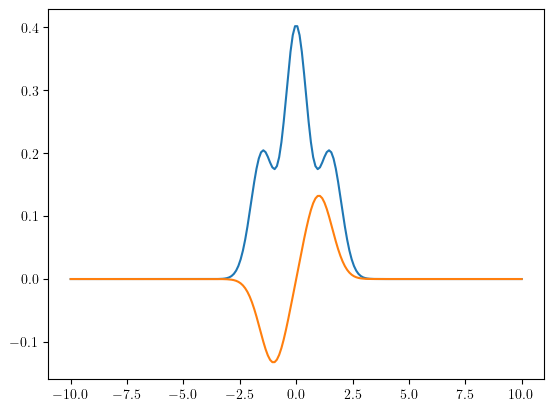

In [93]:
xs = np.linspace(-10,10,200)
A_diag_data = [A_f_diag(xi) for xi in xs]
A_off_data = [A_f_offdiag(xi) for xi in xs]
plt.plot(xs,A_diag_data)
plt.plot(xs,A_off_data )

In [94]:
np.shape(G_w)

(500, 2, 2)

In [95]:
#MiniPole for matrix-valued Green's function
#err: error tolerance. Should be set to no less than the noise level
p = MiniPole(G_w, w, err=1.e-2)


In [96]:
np.shape(p.pole_weight)
#np.shape(p.pole_weight.reshape(-1, n_orb ** 2))
n_orb ** 2

4

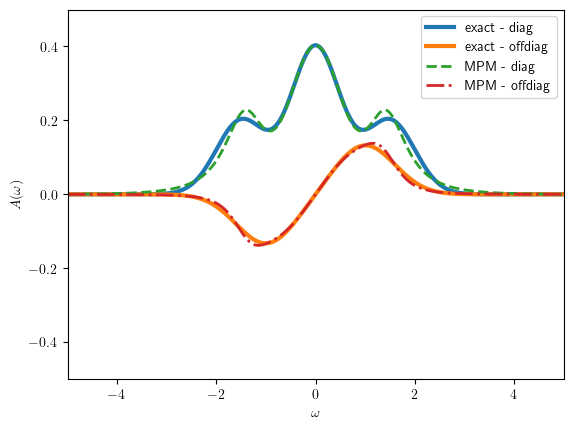

In [97]:
# Analytic continuation results are stored in p.pole_weight (for pole weights) and p.pole_location (for pole locations)
x = np.linspace(-5, 5, 1000)
G_f_r = cal_G_vector(x, p.pole_weight.reshape(-1, n_orb ** 2), p.pole_location).reshape(-1, n_orb, n_orb)


plt.plot(x, A_f_diag(x), linewidth=3, label="exact - diag")
plt.plot(x, A_f_offdiag(x), linewidth=3, label="exact - offdiag")
plt.plot(x, -1.0 / np.pi * G_f_r[:, 0, 0].imag, "--", linewidth=2, label="MPM - diag")
plt.plot(x, -1.0 / np.pi * G_f_r[:, 0, 1].imag, "-.", linewidth=2, label="MPM - offdiag")
plt.legend()
plt.xlim([-5, 5])
plt.ylim([-0.5, 0.5])
plt.xlabel(r"$\omega$")
plt.ylabel(r"$A(\omega)$")
plt.show()

# Example 2. 

In [98]:
# Hilbert transform of a Gaussian function
from scipy.special import dawsn
def hilbert_gaussian(w, mu = 0.0, sigma = 1.0):
    return np.sqrt(2) / (np.pi * sigma) * dawsn((w - mu) / (np.sqrt(2) * sigma))



In [99]:
# given an instance of the MiniPoleRf class p and a list of M, obtain the comlpex pole results
def obt_pol(p, M_list, matrix=False):
    Al_list = []
    xl_list = []
    for M in M_list:
        p.change_M(M)
        if matrix is False:
            Al_list.append(p.pole_weight.reshape(-1, 1))
            xl_list.append(p.pole_location)
        else:
            Al_list.append(p.pole_weight.reshape(-1, 4))
            xl_list.append(p.pole_location)
    return Al_list, xl_list


In [100]:
# compute the recovered density of states and Green's function, along with their deviations from the exact counterparts
def obt_result(Al_list, xl_list, M_list, dos_e, G_R_e, G_w_e):
    dos_r = []
    G_R_r = []
    G_w_r = []
    err_dos_mean = []
    err_dos_max  = []
    err_ret_mean = []
    err_ret_max  = []
    err_Mat_mean = []
    err_Mat_max  = []
    for i in range(len(M_list)):
        Al = Al_list[i]
        xl = xl_list[i]
        dos_r.append(          2 * cal_G(      w, Al, xl).real)
        G_R_r.append(-2j * np.pi * cal_G(      w, Al, xl))
        G_w_r.append(-2j * np.pi * cal_G(1j * wn, Al, xl))
        err_dos_mean.append(np.abs(dos_r[-1] - dos_e).max(axis=1).mean())
        err_dos_max.append( np.abs(dos_r[-1] - dos_e).max(axis=1).max())
        err_ret_mean.append(np.abs(G_R_r[-1].real - G_R_e.real).max(axis=1).mean())
        err_ret_max.append( np.abs(G_R_r[-1].real - G_R_e.real).max(axis=1).max())
        err_Mat_mean.append(np.abs(G_w_r[-1] - G_w_e).max(axis=1).mean())
        err_Mat_max.append( np.abs(G_w_r[-1] - G_w_e).max(axis=1).max())
    return dos_r, G_R_r, G_w_r, err_dos_mean, err_dos_max, err_ret_mean, err_ret_max, err_Mat_mean, err_Mat_max


In [111]:

# list indices of the corresponding results
idx_dos_r = 0
idx_G_R_r = 1
idx_G_w_r = 2
idx_err_dos_mean = 3
idx_err_dos_max  = 4
idx_err_ret_mean = 5
idx_err_ret_max  = 6
idx_err_Mat_mean = 7
idx_err_Mat_max  = 8

In [112]:
# density of states
def kondo_dos(w):
    return 0.2 * gaussian(w, -2, 0.5) + 0.6 * lorentzian(w, half_width=0.01) + 0.2 * gaussian(w, 2, 0.5)

# retarded Green's function
def kondo_G_R(w):
    return 0.2 * np.pi * (hilbert_gaussian(w, -2, 0.5) - 1j * gaussian(w, -2, 0.5)) + 0.6 / (w + 0.01j) + 0.2 * np.pi * (hilbert_gaussian(w, 2, 0.5) - 1j * gaussian(w, 2, 0.5))



In [113]:

# density of states for diagonal elements
def boson_dos_diag(w):
    return -0.6 * gaussian(w, -1.2, 0.8) + 0.6 * gaussian(w, 1.2, 0.8)

# density of states for off-diagonal elements
def boson_dos_offdiag(w):
    return -0.13 * gaussian(w, -1.8, 0.5) + 0.1 * gaussian(w, -1.0, 1.0) - 0.1 * gaussian(w, 1.0, 1.0) + 0.13 * gaussian(w, 1.8, 0.5)

# retarded Green's function for diagonal elements
def boson_G_R_diag(w):
    return -0.6 * np.pi * (hilbert_gaussian(w, -1.2, 0.8) - 1j * gaussian(w, -1.2, 0.8)) + 0.6 * np.pi * (hilbert_gaussian(w, 1.2, 0.8) - 1j * gaussian(w, 1.2, 0.8))

# retarded Green's function for off-diagonal elements
def boson_G_R_offdiag(w):
    return - 0.13 * np.pi * (hilbert_gaussian(w, -1.8, 0.5) - 1j * gaussian(w, -1.8, 0.5)) \
           + 0.10 * np.pi * (hilbert_gaussian(w, -1.0, 1.0) - 1j * gaussian(w, -1.0, 1.0)) \
           - 0.10 * np.pi * (hilbert_gaussian(w,  1.0, 1.0) - 1j * gaussian(w,  1.0, 1.0)) \
           + 0.13 * np.pi * (hilbert_gaussian(w,  1.8, 0.5) - 1j * gaussian(w,  1.8, 0.5))



In [117]:
#### analyticcal data

w = np.linspace(-10, 10, 1000)
wn = np.linspace(0, 100, 100)
# density of states
dos_e1 = kondo_dos(w).reshape(-1, 1)
dos_e2_diag = boson_dos_diag(w); dos_e2_offdiag = boson_dos_offdiag(w)
dos_e2 = np.array([dos_e2_diag, dos_e2_offdiag, dos_e2_offdiag, dos_e2_diag]).T.reshape(-1, 4)
# retarded Green's function
G_R_e1 = kondo_G_R(w).reshape(-1, 1)
G_R_e2_diag = boson_G_R_diag(w); G_R_e2_offdiag = boson_G_R_offdiag(w)
G_R_e2 = np.array([G_R_e2_diag, G_R_e2_offdiag, G_R_e2_offdiag, G_R_e2_diag]).T.reshape(-1, 4)
# Matsubara Green's function
gf = GreenFunc("F", 1, "continuous", A_x= lambda w: 0.2 * gaussian(w, -2, 0.5) + 0.2 * gaussian(w, 2, 0.5), x_min=-np.inf, x_max=np.inf)
G_w_e1 = (gf.get_G(1j * wn) + 0.6 / (1j * wn + 0.01j)).reshape(-1, 1)
gf_diag    = GreenFunc("F", 1, "continuous", A_x=boson_dos_diag   , x_min=-np.inf, x_max=np.inf)
gf_offdiag = GreenFunc("F", 1, "continuous", A_x=boson_dos_offdiag, x_min=-np.inf, x_max=np.inf)
G_w_e2_diag = gf_diag.get_G(1j * wn); G_w_e2_offdiag = gf_offdiag.get_G(1j * wn)
G_w_e2 = np.array([G_w_e2_diag, G_w_e2_offdiag, G_w_e2_offdiag, G_w_e2_diag]).T.reshape(-1, 4)



In [118]:
# obtain results where the final approximation is accurate to within 1.e-12
p1 = MiniPoleRf([kondo_dos], interval_type="infinite", wp_max=2, err=1.e-8, k_max=300)
p2 = MiniPoleRf([boson_dos_diag, boson_dos_offdiag, boson_dos_offdiag, boson_dos_diag], interval_type="infinite", wp_max=2, err=1.e-8, k_max=300)



# obtain results for different values of M using p.change_M(M). Note that the contour integrals h_k can be reused.
M_list1 = np.arange(3, 20, 2)
M_list2 = np.arange(3, 20, 2)

Al_list1, xl_list1 = obt_pol(p1, M_list1)
Al_list2, xl_list2 = obt_pol(p2, M_list2, matrix=True)


# recover the Green's functions and their associated errors
r1 = obt_result(Al_list1, xl_list1, M_list1, dos_e1, G_R_e1, G_w_e1)
r2 = obt_result(Al_list2, xl_list2, M_list2, dos_e2, G_R_e2, G_w_e2)



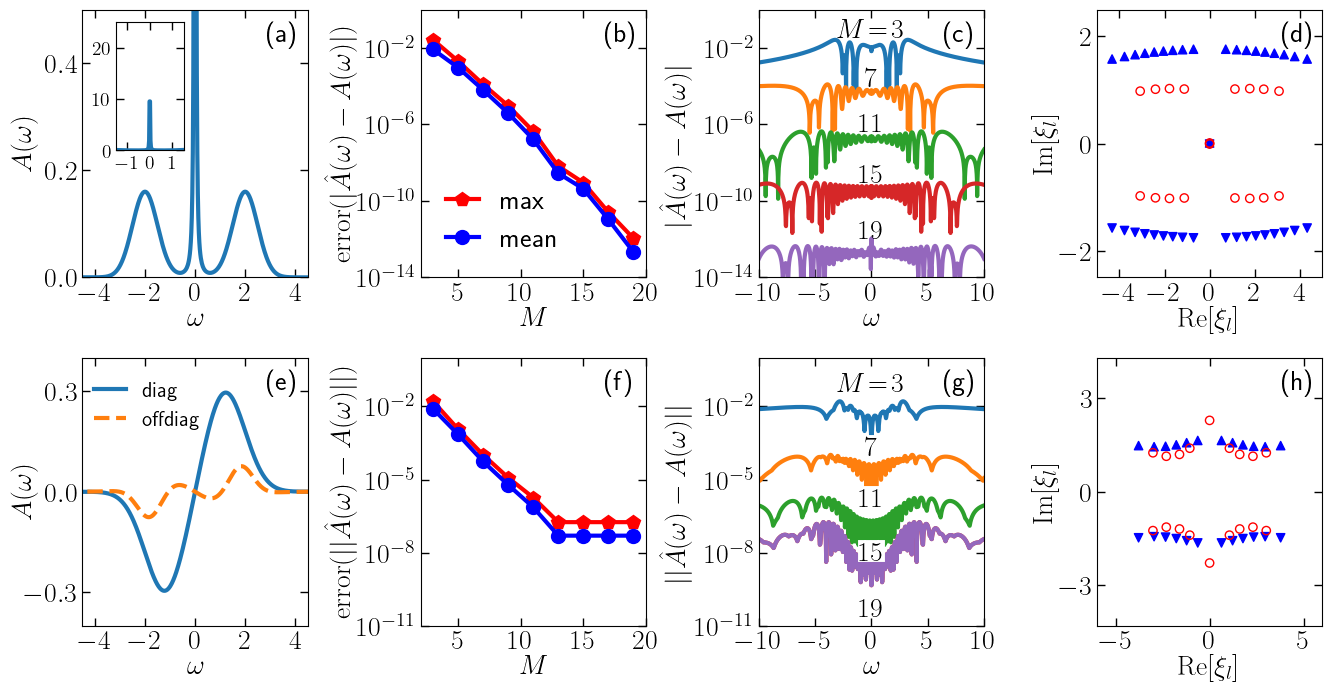

In [110]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import LogLocator
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as patches
plt.rcParams.update({
    'text.usetex': True,
    'font.weight': 'bold',  # Makes the font bold
    'axes.labelweight': 'bold',  # Axis labels bold
    'axes.titleweight': 'bold'   # Title bold
})
colors  = [(1, 1, 1), (0, 0, 1)] #(R, G, B) tuples for white and blue
colors2 = [(1, 1, 1), (1, 0, 0)] #(R, G, B) tuples for white and red
n_bins = 100 #Discretize the interpolation into bins
cmap_name  = "WtBu"
cmap  = LinearSegmentedColormap.from_list(cmap_name , colors , N=n_bins) #Create the colormap

fontsize = 20
labelsize = 20
linewidth = 3
markersize= 10

major_len = 6
major_wid = 1
minor_len = 3
minor_wid = 1

# Create the figure and subplots
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 4, wspace=0.5, hspace=0.3)
(axs0, axs1) = gs.subplots()

# Plot data in the subplots
# Subplot (a)
axs0[0].plot(w, dos_e1, color="tab:blue", linestyle = "-", linewidth=linewidth, label = "Exact")
axs0[0].tick_params(axis="both", which="both", direction="in", pad=3, labelsize=labelsize, right=True, top=True)
axs0[0].tick_params(which="major", length=major_len, width=major_wid)
axs0[0].tick_params(which="minor", length=minor_len, width=minor_wid)
axs0[0].set_xticks([-4, -2, 0, 2, 4])
axs0[0].set_xlim([-4.5, 4.5])
axs0[0].set_ylim([0, 0.5])
axs0[0].set_xlabel(r"$\omega$", labelpad=0, fontsize=fontsize)
axs0[0].set_ylabel(r"$A(\omega)$", labelpad=5, fontsize=fontsize)
axs0[0].annotate("(a)", (0.82, 0.88), xycoords='axes fraction', fontsize=fontsize)

axins0 = inset_axes(axs0[0], width="100%", height="100%", bbox_to_anchor=(.18, .5, .3, .48), bbox_transform=axs0[0].transAxes)
axins0.plot(w, dos_e1, color="tab:blue", linestyle = "-", linewidth=linewidth, label = "Exact")
axins0.tick_params(axis="both", which="both", direction="in", labelsize=labelsize-6, right=True, top=True)
axins0.tick_params(which="major", length=major_len, width=major_wid)
axins0.tick_params(which="minor", length=minor_len, width=minor_wid)
axins0.set_xticks([-1, 0, 1])
axins0.set_yticks([0, 10, 20, 30])
axins0.set_xlim([-1.5, 1.5])
axins0.set_ylim([0, 25])
# Subplot (b)
axs0[1].semilogy(M_list1, r1[idx_err_dos_max] , color="red" , linestyle = "-", linewidth=linewidth, marker="p", markersize=markersize, label="max")
axs0[1].semilogy(M_list1, r1[idx_err_dos_mean], color="blue", linestyle = "-", linewidth=linewidth, marker="o", markersize=markersize, label="mean")
axs0[1].legend(fontsize=fontsize, frameon=False, handlelength=1.2)
axs0[1].tick_params(axis="both", which="both", direction="in", pad=3, labelsize=labelsize, right=True, top=True)
axs0[1].tick_params(which="major", length=major_len, width=major_wid)
axs0[1].tick_params(which="minor", length=minor_len, width=minor_wid)
axs0[1].set_xticks([0, 5, 10, 15, 20])
axs0[1].set_xlim([2, 20])
axs0[1].set_ylim([1e-14, 1e-0])
axs0[1].set_xlabel(r"$M$", labelpad=0, fontsize=fontsize)
axs0[1].set_ylabel(r"${\rm error}(|\hat{A}(\omega) - A(\omega)|)$", labelpad=0, fontsize=fontsize)
axs0[1].annotate("(b)", (0.82, 0.88), xycoords='axes fraction', fontsize=fontsize)
# Subplot (c)
for i in range(0, len(M_list1), 2):
    axs0[2].semilogy(w, np.abs(r1[idx_dos_r][i] - dos_e1), linestyle = "-", linewidth=linewidth)
axs0[2].tick_params(axis="both", which="both", direction="in", pad=3, labelsize=labelsize, right=True, top=True)
axs0[2].tick_params(which="major", length=major_len, width=major_wid)
axs0[2].tick_params(which="minor", length=minor_len, width=minor_wid)
axs0[2].set_xticks([-10, -5, 0, 5, 10])
axs0[2].set_xlim([-10, 10])
axs0[2].set_ylim([1e-14, 1e0])
axs0[2].set_xlabel(r"$\omega$", labelpad=0, fontsize=fontsize)
axs0[2].set_ylabel(r"$|\hat{A}(\omega) - A(\omega)|$", labelpad=2, fontsize=fontsize)
axs0[2].annotate("(c)", (0.82, 0.88), xycoords='axes fraction', fontsize=fontsize)
axs0[2].annotate(r"$M\!=\!3$", (0.5, 0.92), xycoords='axes fraction', ha="center", va="center", fontsize=fontsize)
axs0[2].annotate(r"$7$",       (0.5, 0.74), xycoords='axes fraction', ha="center", va="center", fontsize=fontsize)
axs0[2].annotate(r"$11$",      (0.5, 0.57), xycoords='axes fraction', ha="center", va="center", fontsize=fontsize)
axs0[2].annotate(r"$15$",      (0.5, 0.38), xycoords='axes fraction', ha="center", va="center", fontsize=fontsize)
axs0[2].annotate(r"$19$",      (0.5, 0.17), xycoords='axes fraction', ha="center", va="center", fontsize=fontsize)

# Subplot (d)
scatter0 = axs0[3].scatter(xl_list1[-1].real,  xl_list1[-1].imag, c=np.ones(Al_list1[-1].shape), vmin=0, vmax=1, cmap=cmap, marker="v")
scatter0 = axs0[3].scatter(xl_list1[-1].real, -xl_list1[-1].imag, c=np.ones(Al_list1[-1].shape), vmin=0, vmax=1, cmap=cmap, marker="^")
scatter0 = axs0[3].scatter(xl_list1[3].real ,  xl_list1[3].imag , facecolors="none", edgecolors="red", marker="o")
scatter0 = axs0[3].scatter(xl_list1[3].real , -xl_list1[3].imag , facecolors="none", edgecolors="red", marker="o")
axs0[3].tick_params(axis="both", which="both", direction="in", pad=3, labelsize=labelsize, right=True, top=True)
axs0[3].tick_params(which="major", length=major_len, width=major_wid)
axs0[3].tick_params(which="minor", length=minor_len, width=minor_wid)
axs0[3].set_xticks([-4, -2, 0, 2, 4])
axs0[3].set_xlim([-5, 5])
axs0[3].set_ylim([-2.5, 2.5])
axs0[3].set_xlabel(r"${\rm Re}[\xi_l]$", labelpad=0, fontsize=fontsize)
axs0[3].set_ylabel(r"${\rm Im}[\xi_l]$", labelpad=0, fontsize=fontsize)
axs0[3].annotate("(d)", (0.82, 0.88), xycoords='axes fraction', fontsize=fontsize)

# Subplot (e)
axs1[0].plot(w, dos_e2[:, 0], color="tab:blue"  , linestyle = "-" , linewidth=linewidth, label = "diag")
axs1[0].plot(w, dos_e2[:, 1], color="tab:orange", linestyle = "--", linewidth=linewidth, label = "offdiag")
axs1[0].legend(fontsize=fontsize-5, frameon=False, loc="upper left", bbox_to_anchor=(-0.03, 0.98), handlelength=1.5)
axs1[0].tick_params(axis="both", which="both", direction="in", pad=3, labelsize=labelsize, right=True, top=True)
axs1[0].tick_params(which="major", length=major_len, width=major_wid)
axs1[0].tick_params(which="minor", length=minor_len, width=minor_wid)
axs1[0].set_xticks([-4, -2, 0, 2, 4])
axs1[0].set_yticks([-0.3, 0, 0.3])
axs1[0].set_xlim([-4.5, 4.5])
axs1[0].set_ylim([-0.4, 0.4])
axs1[0].set_xlabel(r"$\omega$", labelpad=0, fontsize=fontsize)
axs1[0].set_ylabel(r"$A(\omega)$", labelpad=-10, fontsize=fontsize)
axs1[0].annotate("(e)", (0.82, 0.88), xycoords='axes fraction', fontsize=fontsize)

# Subplot (f)
axs1[1].semilogy(M_list2, r2[idx_err_dos_max] , color="red" , linestyle = "-", linewidth=linewidth, marker="p", markersize=markersize, label="max")
axs1[1].semilogy(M_list2, r2[idx_err_dos_mean], color="blue", linestyle = "-", linewidth=linewidth, marker="o", markersize=markersize, label="mean")
axs1[1].tick_params(axis="both", which="both", direction="in", pad=3, labelsize=labelsize, right=True, top=True)
axs1[1].tick_params(which="major", length=major_len, width=major_wid)
axs1[1].tick_params(which="minor", length=minor_len, width=minor_wid)
axs1[1].set_xticks([0, 5, 10, 15, 20])
axs1[1].set_xlim([2, 20])
axs1[1].set_ylim([1e-11, 1e-0])
axs1[1].set_xlabel(r"$M$", labelpad=0, fontsize=fontsize)
axs1[1].set_ylabel(r"${\rm error}(||\hat{A}(\omega) - A(\omega)||)$", labelpad=0, fontsize=fontsize)
axs1[1].annotate("(f)", (0.82, 0.88), xycoords='axes fraction', fontsize=fontsize)

# Subplot (g)
for i in range(0, len(M_list2), 2):
    axs1[2].semilogy(w, np.abs(r2[idx_dos_r][i] - dos_e2).max(axis=1), linestyle = "-", linewidth=linewidth)
axs1[2].tick_params(axis="both", which="both", direction="in", pad=3, labelsize=labelsize, right=True, top=True)
axs1[2].tick_params(which="major", length=major_len, width=major_wid)
axs1[2].tick_params(which="minor", length=minor_len, width=minor_wid)
axs1[2].set_xticks([-10, -5, 0, 5, 10])
axs1[2].set_xlim([-10, 10])
axs1[2].set_ylim([1e-11, 1e-0])
axs1[2].set_xlabel(r"$\omega$", labelpad=0, fontsize=fontsize)
axs1[2].set_ylabel(r"$||\hat{A}(\omega) - A(\omega)||$", labelpad=2, fontsize=fontsize)
axs1[2].annotate("(g)", (0.82, 0.88), xycoords='axes fraction', fontsize=fontsize)
rect1 = patches.Rectangle((0.47, 0.655), 0.06, 0.03, transform=axs1[2].transAxes, linewidth=10, edgecolor='white', facecolor='white', zorder=2)
rect2 = patches.Rectangle((0.47, 0.465), 0.06, 0.03, transform=axs1[2].transAxes, linewidth=10, edgecolor='white', facecolor='white', zorder=2)
rect3 = patches.Rectangle((0.47, 0.265), 0.06, 0.03, transform=axs1[2].transAxes, linewidth=10, edgecolor='white', facecolor='white', zorder=2)
rect4 = patches.Rectangle((0.47, 0.055), 0.06, 0.03, transform=axs1[2].transAxes, linewidth=10, edgecolor='white', facecolor='white', zorder=2)
axs1[2].add_patch(rect1)
axs1[2].add_patch(rect2)
axs1[2].add_patch(rect3)
axs1[2].add_patch(rect4)
axs1[2].annotate(r"$M\!=\!" + str(M_list2[0]) + "$", (0.5, 0.90), xycoords='axes fraction', ha="center", va="center", fontsize=fontsize)
axs1[2].annotate(r"$"       + str(M_list2[2]) + "$", (0.5, 0.66), xycoords='axes fraction', ha="center", va="center", fontsize=fontsize)
axs1[2].annotate(r"$"       + str(M_list2[4]) + "$", (0.5, 0.47), xycoords='axes fraction', ha="center", va="center", fontsize=fontsize)
axs1[2].annotate(r"$"       + str(M_list2[6]) + "$", (0.5, 0.27), xycoords='axes fraction', ha="center", va="center", fontsize=fontsize)
axs1[2].annotate(r"$"       + str(M_list2[8]) + "$", (0.5, 0.06), xycoords='axes fraction', ha="center", va="center", fontsize=fontsize)

# Subplot (h)
scatter1 = axs1[3].scatter(xl_list2[-1].real,  xl_list2[-1].imag, c=np.ones(xl_list2[-1].shape), vmin=0, vmax=1, cmap=cmap, marker="v")
scatter1 = axs1[3].scatter(xl_list2[-1].real, -xl_list2[-1].imag, c=np.ones(xl_list2[-1].shape), vmin=0, vmax=1, cmap=cmap, marker="^")
scatter1 = axs1[3].scatter(xl_list2[3].real ,  xl_list2[3].imag , facecolors="none", edgecolors="red", marker="o")
scatter1 = axs1[3].scatter(xl_list2[3].real , -xl_list2[3].imag , facecolors="none", edgecolors="red", marker="o")
axs1[3].tick_params(axis="both", which="both", direction="in", pad=3, labelsize=labelsize, right=True, top=True)
axs1[3].tick_params(which="major", length=major_len, width=major_wid)
axs1[3].tick_params(which="minor", length=minor_len, width=minor_wid)
axs1[3].set_xticks([-5, 0, 5])
axs1[3].set_yticks([-3, 0, 3])
axs1[3].set_xlim([-6, 6])
axs1[3].set_ylim([-4.3, 4.3])
axs1[3].set_xlabel(r"${\rm Re}[\xi_l]$", labelpad=0, fontsize=fontsize)
axs1[3].set_ylabel(r"${\rm Im}[\xi_l]$", labelpad=0, fontsize=fontsize)
axs1[3].annotate("(h)", (0.82, 0.88), xycoords='axes fraction', fontsize=fontsize)

plt.show()

In [132]:
np.shape(r2[idx_dos_r])

(9, 1000, 4)

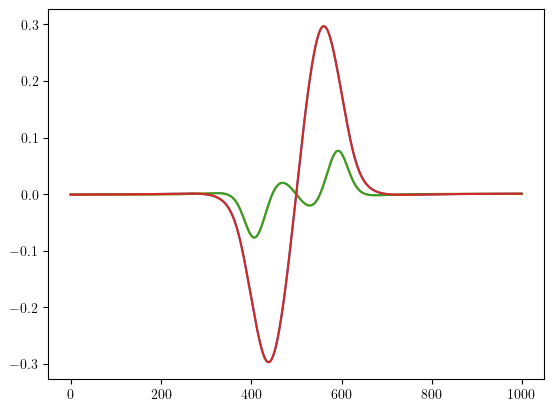

In [138]:
plt.plot((r2[idx_dos_r])[1][:,0])
plt.plot((r2[idx_dos_r])[1][:,1])
plt.plot((r2[idx_dos_r])[1][:,2])
plt.plot((r2[idx_dos_r])[1][:,3])


Text(0.82, 0.88, '(f)')

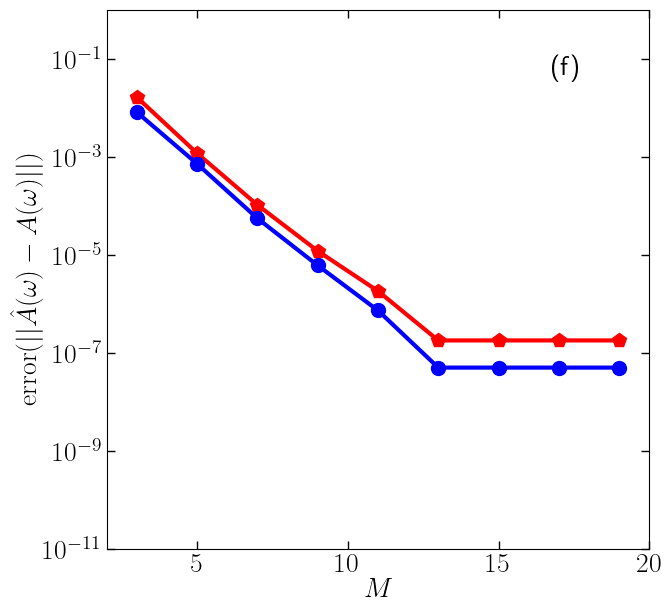

In [120]:

fig,axs1 = plt.subplots(figsize=(7, 7))
# Subplot (f)
axs1.semilogy(M_list2, r2[idx_err_dos_max] , color="red" , linestyle = "-", linewidth=linewidth, marker="p", markersize=markersize, label="max")
axs1.semilogy(M_list2, r2[idx_err_dos_mean], color="blue", linestyle = "-", linewidth=linewidth, marker="o", markersize=markersize, label="mean")
axs1.tick_params(axis="both", which="both", direction="in", pad=3, labelsize=labelsize, right=True, top=True)
axs1.tick_params(which="major", length=major_len, width=major_wid)
axs1.tick_params(which="minor", length=minor_len, width=minor_wid)
axs1.set_xticks([0, 5, 10, 15, 20])
axs1.set_xlim([2, 20])
axs1.set_ylim([1e-11, 1e-0])
axs1.set_xlabel(r"$M$", labelpad=0, fontsize=fontsize)
axs1.set_ylabel(r"${\rm error}(||\hat{A}(\omega) - A(\omega)||)$", labelpad=0, fontsize=fontsize)
axs1.annotate("(f)", (0.82, 0.88), xycoords='axes fraction', fontsize=fontsize)


Text(0.82, 0.88, '(e)')

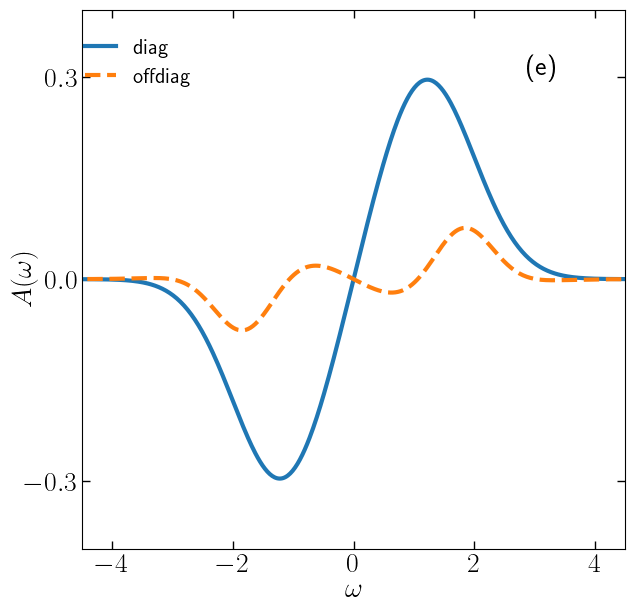

In [116]:
### Analytical data 

fig,axs1 = plt.subplots(figsize=(7, 7))

axs1.plot(w, dos_e2[:, 0], color="tab:blue"  , linestyle = "-" , linewidth=linewidth, label = "diag")
axs1.plot(w, dos_e2[:, 1], color="tab:orange", linestyle = "--", linewidth=linewidth, label = "offdiag")
axs1.legend(fontsize=fontsize-5, frameon=False, loc="upper left", bbox_to_anchor=(-0.03, 0.98), handlelength=1.5)
axs1.tick_params(axis="both", which="both", direction="in", pad=3, labelsize=labelsize, right=True, top=True)
axs1.tick_params(which="major", length=major_len, width=major_wid)
axs1.tick_params(which="minor", length=minor_len, width=minor_wid)
axs1.set_xticks([-4, -2, 0, 2, 4])
axs1.set_yticks([-0.3, 0, 0.3])
axs1.set_xlim([-4.5, 4.5])
axs1.set_ylim([-0.4, 0.4])
axs1.set_xlabel(r"$\omega$", labelpad=0, fontsize=fontsize)
axs1.set_ylabel(r"$A(\omega)$", labelpad=-10, fontsize=fontsize)
axs1.annotate("(e)", (0.82, 0.88), xycoords='axes fraction', fontsize=fontsize)

### Example on a Semicircle 

In [256]:
import matplotlib.pyplot as plt 


import numpy as np

def gr_n(eps, n, gamma=1.0, gamma_c=1.0, Ny=5):
    """
    Retarded GF in the diagonal transverse channel basis.
    eps: energy (float or complex)
    n: transverse mode index (1..Ny)
    """
    eps_n = -2.0 * gamma * np.cos(n * np.pi / (Ny + 1.0))
    Delta = 4.0 * gamma**2 - (eps - eps_n)**2

    if np.real(Delta) > 0:
        Sigma = eps - eps_n - 1j * np.sqrt(Delta)
    else:
        if np.real(eps - eps_n) > 0:
            sgn = 1.0
        else:
            sgn = -1.0
        Sigma = eps - eps_n - sgn * np.sqrt(-Delta)

    Sigma *= (gamma_c**2) / (2.0 * gamma**2)
    return Sigma


def Gamma_ij(eps, i, j, gamma=1.0, gamma_c=1.0, Ny=2):
    """
    Components of the Gamma function in the lattice basis.
    i, j: transverse site indices (1..Ny), same convention as Julia.
    """

    def Gamma_channel(eps, n):
        return -2.0 * np.imag(gr_n(eps, n=n, gamma=gamma, gamma_c=gamma_c, Ny=Ny))

    def U_in(idx, n):
        return np.sin(n * idx * np.pi / (Ny + 1.0)) * np.sqrt(2.0 / (Ny + 1.0))

    res = 0.0
    for n_s in range(1, Ny + 1):  # 1..Ny, like Julia
        res += U_in(i, n_s) * Gamma_channel(eps, n_s) * U_in(j, n_s)

    return res




np.float64(1.7022935432988975)

In [268]:
G11 = lambda E: Gamma_ij(E,1,1)
G12 = lambda E: Gamma_ij(E,1,2)
G22 = lambda E: Gamma_ij(E,2,2)
# #G11(E) = Gamma_ij(E,1,1)


In [267]:
# #ws
# val1 = [ G11(wi) for wi in ws]
# plt.plot(ws, val1)

In [ ]:
ws = np.linspace(-5,5, 200)
#y_square = [square_lattice_dos(wi) for wi in ws]
y_bethe = [bethe_lattice_dos(wi) for wi in ws]
plt.plot(ws,y_bethe)


In [1456]:
### Example function to calculate square Self energy 

# compute the recovered density of states and Green's function, along with their deviations from the exact counterparts
def obt_result(Al_list,
               xl_list,
               M_list,
               dos_e,
               G_R_e,
               G_w_e):
    dos_r = []
    G_R_r = []
    G_w_r = []

    for i in range(len(M_list)):
        Al = Al_list[i]
        xl = xl_list[i]
        dos_r.append( 2 * cal_G(      w, Al, xl).real)
        G_R_r.append(-2j * np.pi * cal_G(      w, Al, xl))
        G_w_r.append(-2j * np.pi * cal_G(1j * wn, Al, xl))

    return dos_r, G_R_r, G_w_r

# density of states for diagonal elements
#def boson_dos_diag(w):
#    return -0.6 * gaussian(w, -1.2, 0.8) + 0.6 * gaussian(w, 1.2, 0.8)
# density of states for off-diagonal elements
#def boson_dos_offdiag(w):
#    return -0.13 * gaussian(w, -1.8, 0.5) + 0.1 * gaussian(w, -1.0, 1.0) - 0.1 * gaussian(w, 1.0, 1.0) + 0.13 * gaussian(w, 1.8, 0.5)

# obtain results where the final approximation is accurate to within 1.e-12
 ##### From this elements we got 
# obtain results for different values of M using p.change_M(M). Note that the contour integrals h_k can be reused.
#M_list2 = np.arange(3, 20, 2)





In [1455]:
#p2 = MiniPoleRf([G11 , G12, G12, G22], interval_type="infinite", wp_max=3, err=1.e-8, k_max=1000)

In [685]:
p2

In [1300]:
#p2 = MiniPoleRf([G11 , G12, G12, G22], interval_type="infinite", wp_max=5, err=1.e-8, k_max=1000)
p3 = MiniPoleRf([bethe_lattice_dos], interval_type="infinite", wp_max=3, err=1.e-11, k_max=1000)
#A_moll_interp

In [1718]:
p3 = MiniPoleRf([A_moll_interp], interval_type="infinite", wp_max=3, err=1.e-11, k_max=2000)
#p3 = MiniPoleRf([A_moll_interp_add_zero], interval_type="infinite", wp_max=3, err=1.e-11, k_max=2000)

In [1762]:
#p3 = MiniPoleRf([bethe_lattice_dos], interval_type="infinite", wp_max=3, sing_vals=[-2,2], err=1e-6, M=20, k_max=1000)
p2=p3

In [1763]:
# Al_list = []
# xl_list = []
# #Al_list.append(p2.pole_weight.reshape(-1, 4))
# Al_list.append(p2.pole_weight)
# xl_list.append(p2.pole_location)

# np.shape(Al_list)

# #p2.pole_weight.reshape(-1, 4)
np.shape(p2.pole_location)

# idx2 = p2.pole_location.imag < 0
# idx2
# p2.pole_location[idx2].reshape(-1, 4)

(49,)

In [1764]:
# idx2 = p2.pole_location.imag < 0
# #p2.pole_location
# print(p2.pole_location.size)
# print(idx2.size)
# Al_list = []
# xl_list = []
# Al_list.append(p2.pole_weight[idx2].reshape(-1, 4))
# xl_list.append(p2.pole_location[idx2])

# np.shape(Al_list)

# #p2.pole_weight.reshape(-1, 4)
# p2.pole_location

# idx2
# p2.pole_location[idx2].reshape(-1, 4)

In [1765]:
#np.shape(Al_list)


In [1766]:
#p2.pole_location.imag

In [1767]:
#p2.pole_location

In [1768]:
w = np.linspace(-5, 5, 100)
# #ws = np.linspace(-5,5, 200)
# #y_square = [square_lattice_dos(wi) for wi in ws]
# y_bethe = [bethe_lattice_dos(wi) for wi in w]

# calculate the Green's function from its complex poles
 #calculate the Green's function from its complex poles
def cal_G(z, Al, xl):
    G_z = 0.0
    for i in range(xl.size):
        G_z += Al[[i]] / (z.reshape(-1, 1) - xl[i])
    return G_z





In [1769]:

#p2 = MiniPoleRf([bethe_lattice_dos , bethe_lattice_dos, bethe_lattice_dos, bethe_lattice_dos ], interval_type="infinite", wp_max=2, err=1.e-8, k_max=800) ##### From this elements we got 



In [1860]:
#tools for calculating the Green's function from the corresponding poles
def cal_G_scalar(z, Al, xl):
    G_z = 0.0
    for i in range(xl.size):
        G_z += -1j*Al[i] / (z - xl[i])
    return G_z

# def project_positive_poles(Al, xl, tol_weight=1e-12):
#     Al_new = []
#     xl_new = []
#     for A, x in zip(Al, xl):
#         # llevar peso a real
#         A_real = np.real(A)
#         # reflejar polo si Im(x) > 0
#         if np.imag(x) > 0:
#             x = np.conj(x)
#             A_real = np.conj(A_real)  # para el caso complejo, aquí ajustarías más fino
#         # descartar pesos muy pequeños o negativos pequeños
#         if A_real < 0 and abs(A_real) < tol_weight:
#             continue  # quitar polo "tiny negativo"
#         # si es muy negativo en magnitud, ojo: esto ya es problema serio
#         if A_real < 0 and abs(A_real) >= tol_weight:
#             # aquí o bien rechazas la proyección,
#             # o lo tratas de forma más sofisticada
#             pass
#         Al_new.append(A_real)
#         xl_new.append(x)
#     return np.array(Al_new), np.array(xl_new)


In [1861]:
idx2 = p2.pole_location.imag < 0
#p2.pole_location
print(p2.pole_location.size)
print(idx2.size)
#Al_list = []
#xl_list = []
p2.pole_weight[idx2]#.reshape(-1, 1))
p2.pole_location[idx2]

33
33


array([-2.09231763e+00-0.00987017j, -2.08870111e+00-0.02006658j,
       -2.08268334e+00-0.03668857j, -2.06993822e+00-0.06313743j,
       -2.03738031e+00-0.10273636j, -1.96941703e+00-0.20572254j,
       -1.96040503e+00-0.11711939j, -1.94477275e+00-0.37403386j,
       -1.92706751e+00-0.06445868j, -1.91596509e+00-0.03647448j,
       -1.91072119e+00-0.01977733j, -1.90742889e+00-0.00972177j,
       -1.87357511e+00-0.60922032j, -1.71051011e+00-0.93617246j,
       -1.37486618e+00-1.33802586j, -7.91272158e-01-1.70954487j,
        3.83601593e-15-1.86750812j,  7.91272158e-01-1.70954487j,
        1.37486618e+00-1.33802586j,  1.71051011e+00-0.93617246j,
        1.87357511e+00-0.60922032j,  1.90742889e+00-0.00972177j,
        1.91072119e+00-0.01977733j,  1.91596509e+00-0.03647448j,
        1.92706751e+00-0.06445868j,  1.94477275e+00-0.37403386j,
        1.96040503e+00-0.11711939j,  1.96941703e+00-0.20572254j,
        2.03738031e+00-0.10273636j,  2.06993822e+00-0.06313743j,
        2.08268334e+00-0.

In [1862]:
#Al_list

In [1863]:
#cal_G(      w, As, zs)
# p2.change_M(60)
# w = np.linspace(-8, 8, 300)
# As = p2.pole_weight.reshape(-1, 4)
p2.change_M(33)

w = np.linspace(-8, 8, 200)
####A11,x11 = project_positive_poles(p2.pole_weight[idx2], p2.pole_location[idx2])
# zs = p2.pole_location
# #zs[0]
#dos_r =  2 * cal_G(      w, p2.pole_weight.reshape(-1, 4), p2.pole_location[idx2]).real#.real
dos_r =  2 * cal_G_scalar(      w, p2.pole_weight, p2.pole_location)#.real#.real
######dos2_r =  2 * cal_G_scalar(      w, A11, x11).real
# G_R_r=-2j * np.pi * cal_G(      w, As, zs)

In [1864]:
# np.shape(dos_r[1]) 
# min(dos_r[:,1])
np.min(dos_r)
#w
#w
dos_r
p2.pole_location.real

array([-2.09231763e+00, -2.08870111e+00, -2.08268334e+00, -2.06993822e+00,
       -2.03738031e+00, -1.96941703e+00, -1.96040503e+00, -1.94477275e+00,
       -1.92706751e+00, -1.91596509e+00, -1.91072119e+00, -1.90742889e+00,
       -1.87357511e+00, -1.71051011e+00, -1.37486618e+00, -7.91272158e-01,
        3.83601593e-15,  7.91272158e-01,  1.37486618e+00,  1.71051011e+00,
        1.87357511e+00,  1.90742889e+00,  1.91072119e+00,  1.91596509e+00,
        1.92706751e+00,  1.94477275e+00,  1.96040503e+00,  1.96941703e+00,
        2.03738031e+00,  2.06993822e+00,  2.08268334e+00,  2.08870111e+00,
        2.09231763e+00])

In [1865]:
p2.pole_weight

array([[[ 2.13678268e-08+5.51086004e-08j]],

       [[-1.08209846e-06+1.40688508e-06j]],

       [[-1.86452917e-05+1.10990299e-06j]],

       [[-8.92197078e-05-8.42304056e-05j]],

       [[ 1.44989828e-04-6.95437159e-04j]],

       [[ 2.70459093e-03-2.19927672e-03j]],

       [[ 1.42225987e-03+1.32865499e-04j]],

       [[ 5.61580933e-03-2.67771425e-03j]],

       [[ 7.11888298e-05+1.15889521e-04j]],

       [[-4.07393386e-06+1.80660478e-05j]],

       [[-1.45092695e-06+8.20521316e-07j]],

       [[-4.65161555e-08-2.58868052e-08j]],

       [[ 1.14781946e-02-2.82885005e-03j]],

       [[ 2.15688361e-02+1.03281848e-03j]],

       [[ 3.23303566e-02+1.56930024e-02j]],

       [[ 2.87045736e-02+4.21484888e-02j]],

       [[-3.19881879e-15+5.78369693e-02j]],

       [[-2.87045736e-02+4.21484888e-02j]],

       [[-3.23303566e-02+1.56930024e-02j]],

       [[-2.15688361e-02+1.03281848e-03j]],

       [[-1.14781946e-02-2.82885005e-03j]],

       [[ 4.65161555e-08-2.58868052e-08j]],

       [[ 

(-8.5, 8.5)

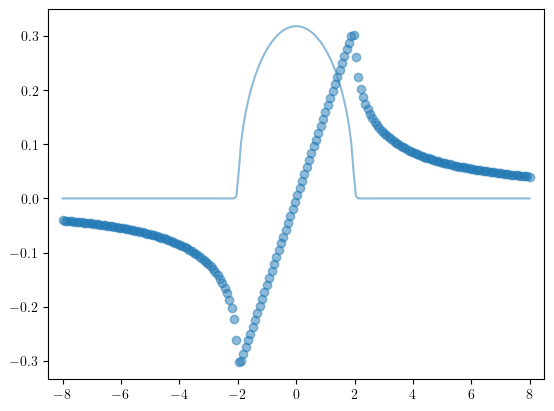

In [1868]:
#plt.scatter(w,np.abs(dos_r[:,1]) )
#plt.scatter(w, np.abs(dos_r))#[:,1] )
#plt.scatter(w, dos_r - np.min(dos_r))
plt.scatter(w, dos_r.real,alpha=0.5 )
plt.plot(w, -dos_r[0,:].imag,alpha=0.5 )
#plt.scatter(w, dos2_r)
#plt.scatter(w,dos_r[:,1] )
#plt.ylim(-1e-9,2e-9)



#plt.ylim(-1e-11,1e-11)
#plt.plot(w,G_R_r)
#plt.xlim(-5,-1.8)
plt.xlim(-8.5,8.5)

#np.shape(dos_r) 

In [1792]:
cal_G_scalar(      0.1, p2.pole_weight, p2.pole_location).real

array([[0.15892429]])

In [1811]:
### Thus we can build the general matrix elemtns justt using the semicircle 
def Gamma_ij_n(eps, i, j, gamma=1.0, gamma_c=1.0, Ny=500):
    """
    Components of the Gamma function in the lattice basis.
    i, j: transverse site indices (1..Ny), same convention as Julia.
    """
    def Gamma_channel(eps, n):
        eps_n = -2.0 * gamma * np.cos(n * np.pi / (Ny + 1.0))
        return 2 * cal_G_scalar( eps- eps_n , p2.pole_weight, p2.pole_location).real
        #-2.0 * np.imag(gr_n(eps, n=n, gamma=gamma, gamma_c=gamma_c, Ny=Ny))
    #dos_r =  2 * cal_G_scalar(      w, p2.pole_weight, p2.pole_location).real
    def U_in(idx, n):
        return np.sin(n * idx * np.pi / (Ny + 1.0)) * np.sqrt(2.0 / (Ny + 1.0))
    res = 0.0
    for n_s in range(1, Ny + 1):  # 1..Ny, like Julia
        res += U_in(i, n_s) * Gamma_channel(eps, n_s) * U_in(j, n_s)
    return res

G11 = lambda E: Gamma_ij_n(E,1,1)
G12 = lambda E: Gamma_ij_n(E,1,2)
G21 = lambda E: Gamma_ij_n(E,2,1)
G22 = lambda E: Gamma_ij_n(E,2,2)

(-1e-07, 1e-07)

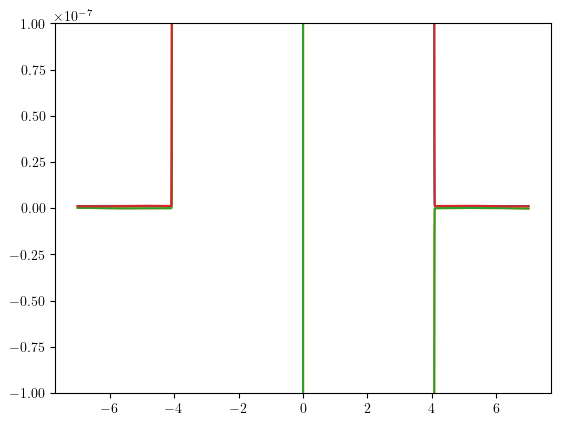

In [1816]:
#np.where( dos_r[:,1] < 00, dos_r[:,1])
wss = np.linspace(-7,7,2000)
plt.plot(wss,G11(wss)[0])
plt.plot(wss,G21(wss)[0])
plt.plot(wss,G12(wss)[0])
plt.plot(wss,G22(wss)[0])
plt.ylim(-1e-7,1e-7)

In [1259]:
M_list2 = np.arange(3, 20, 2)
Al_list2, xl_list2 = obt_pol(p2, M_list2, matrix=True)
#recover the Green's functions and their associated errors 
r2 = obt_result(Al_list2, xl_list2, M_list2, dos_e2, G_R_e2, G_w_e2) 

ValueError: cannot reshape array of size 3 into shape (4)

In [212]:
#np.shape(r2[1])

(9, 1000, 4)

(-1e-08, 1e-08)

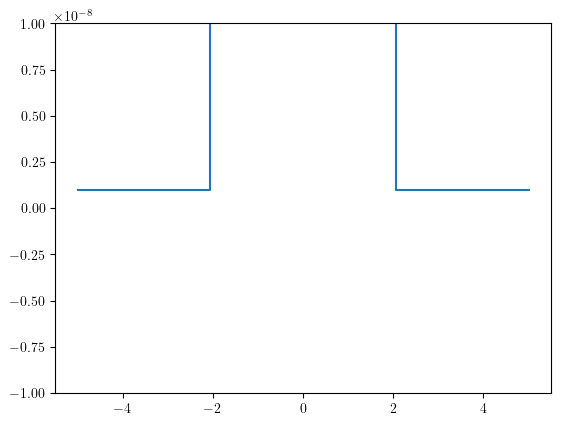

In [991]:


wss=np.linspace(-10,10,1000)
w = np.linspace(-5, 5, 100)
# #ws = np.linspace(-5,5, 200)
# #y_square = [square_lattice_dos(wi) for wi in ws]
y_bethe = [bethe_lattice_dos(wi) for wi in w]
# plt.plot(wss,(r2[0])[1][:,0])
# plt.plot(wss,(r2[0])[8][:,0])
plt.plot(w,y_bethe)
#plt.plot(wss,(r2[1])[1][:,0])
plt.ylim(-1e-8,1e-8)
#plt.plot((r2[0])[1][:,1])
#plt.plot((r2[0])[1][:,2])
#plt.plot((r2[0])[1][:,3])




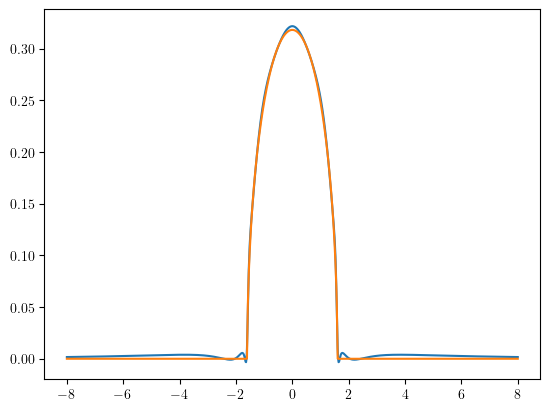

In [186]:
plt.plot(wss,(r2[0])[1][:,0])
plt.plot(wss,(r2[0])[5][:,0])

# Analytical expression of the Selfenergy for square lattice 

In [ ]:
def Σ_1d(ϵ::ComplexF64; γ::Float64=1. ,γc::Float64=1.)
    Δ = 4 * γ^2 - ϵ^2
    if real(Δ) > 0
        Σ = ϵ - im * sqrt(Δ)
    else
        if real(ϵ) > 0
            sgn = 1
        else
            sgn = -1
        end
        Σ = ϵ - sgn * sqrt(-Δ)
    end
    Σ = Σ* (γc^2 / (2 * γ^2))
    return Σ
end

# Examples of analitical spectral functions

In [1716]:
def bump_kernel(dw, eps, n_sigma=1.0):
    """
    Construye un kernel bump discreto, centrado en 0, de soporte ~[-eps, eps].
    dw      : spacing de la malla de frecuencia
    eps     : ancho del bump (en unidades de frecuencia)
    n_sigma : factor para decidir el tamaño del kernel en múltiplos de eps
    """
    # tamaño del kernel en puntos (lo hago un poco más grande que eps para seguridad)
    half_width = int(np.ceil(n_sigma * eps / dw))
    x = np.arange(-half_width, half_width + 1) * dw

    kernel = np.zeros_like(x, dtype=float)
    mask = np.abs(x) < eps
    y = x[mask] / eps
    kernel[mask] = np.exp(1.0 / (y**2 - 1.0))

    # normalizar para que int kernel dx ≈ 1
    norm = np.sum(kernel) * dw
    if norm > 0:
        kernel /= norm

    return kernel


from scipy.interpolate import interp1d

def make_bethe_mollified_dos(t=1.0, eps_factor=0.1,
                             w_min_factor=10.0, w_max_factor=10.0,
                             n_w=4001):
    # Generates the grid with the desired number of points
    # and determine the equal spacing between the points 
    t = float(t)
    w_min = -w_min_factor * t
    w_max =  w_max_factor * t
    w_grid = np.linspace(w_min, w_max, n_w)
    dw = w_grid[1] - w_grid[0]

    # DOS Bethe original
    A_bethe = bethe_lattice_dos(w_grid, t=t)

    # mollifier
    eps = eps_factor * t
    kernel = bump_kernel(dw, eps)

    # convolución discreta
    A_moll = np.convolve(A_bethe, kernel, mode="same")

    # renormalizar el área con Simpson
    area = simpson(A_moll, w_grid)
    if area > 0:
        A_moll /= area

    A_moll_interp = interp1d(
        w_grid, A_moll,
        kind="linear",
        bounds_error=False,
        fill_value= 0.0#1e-9*0.5
    )

    return w_grid, A_bethe, A_moll, A_moll_interp

# construir DOS mollificada
w_grid, A_bethe, A_moll, A_moll_interp = make_bethe_mollified_dos(
    t=1.0, eps_factor=0.1, n_w=800001
)

#### Extra addition of zero value 
def A_moll_interp_add_zero(ω):
    val = A_moll_interp(ω)
    return np.where(val < 1e-9, 2e-9, val)

# función que le vas a pasar a MiniPoleRf
# def G_rf(omega):
#     # si MiniPoleRf espera la DOS real directamente:
#     return A_moll_interp(omega)

# luego:
# p2 = MiniPoleRf([G_rf], interval_type="infinite", wp_max=2, err=1e-12, k_max=3000)


(-1e-08, 1e-08)

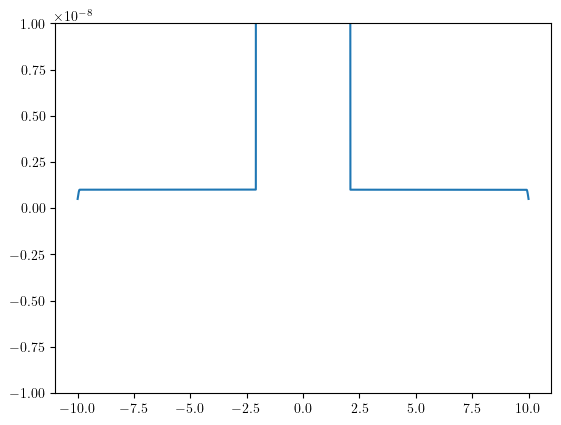

In [1817]:
plt.plot(w_grid,A_moll)
#plt.xlim(-2.2,-1.9)
plt.ylim(-1e-8,1e-8)

In [1719]:
w_grid

wsss= np.linspace(-11,11,400)
np.min(A_moll_interp(wsss))

np.float64(0.0)

(-1e-09, 3e-09)

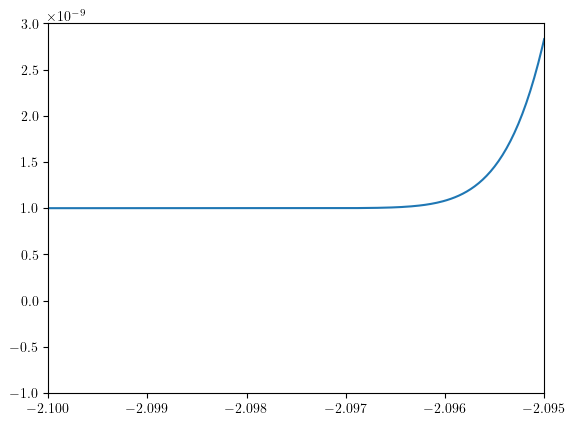

In [1693]:
#w_grid

plt.plot(w_grid,A_moll_interp(w_grid) )
plt.plot(wsss,A_moll_interp_add_zero(wsss),color="red")
plt.plot(wsss,A_moll_interp(wsss) )
plt.xlim(-2.1,-2.095)
#.ylim(-1e-10 +1e-9 ,1e-9 +2e-10)
plt.ylim(-1e-9,3e-9 )
#plt.xlim(1.9,2.1)

In [1450]:

# plt.plot(w_grid,A_moll(w_grid) )
# plt.xlim(-2.1,-1.9)
# plt.xlim(1.9,2.1)

(-2.1, -1.9)

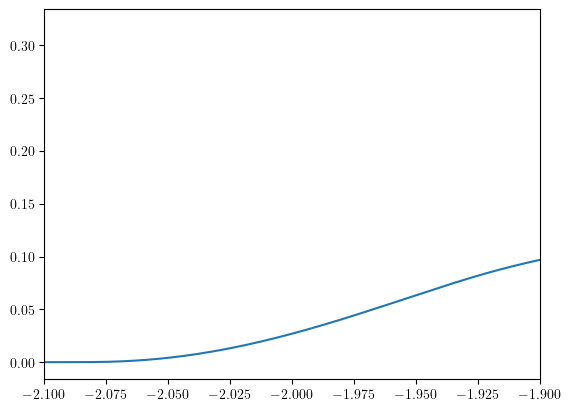

In [1451]:
plt.plot(w_grid,A_moll_interp(w_grid) )
plt.xlim(-2.1,-1.9)

In [1869]:
import numpy as np
from scipy.special import ellipk

'''
Function tools for testing the performance of Prony Analytic Continuation.
'''
def fermi(w,kT = 10):
    return 1/(np.exp(w/kT)+1)
    
def semi_circle(w, w0 = 0.0, r = 1.0):
    '''
    A semicircle function with the center being w0 and the radius being r.
    '''
    assert r > 0.0
    if np.abs(w - w0) >= r:
        return 0.0
    else:
        return (2.0 / (np.pi * r**2.0)) * np.sqrt(r**2.0 - (w - w0)**2.0)

def rectangle(w, w0 = 0.0, dw_h = 0.5):
    '''
    A rectangle function with the center being w0 and the half-width being dw_h.
    '''
    assert dw_h > 0.0
    if np.abs(w - w0) >= dw_h:
        return 0.0
    else:
        return 1.0 / (2.0 * dw_h)

def triangle(w, w0 = 0.0, dw_h = 1.0):
    '''
    A triangle function with the center being w0 and the half-length of the bottom edge being dw_h.
    '''
    assert dw_h > 0.0
    if np.abs(w - w0) >= dw_h:
        return 0.0
    else:
        h = 1.0 / dw_h
        return h * (1.0 - np.abs(w - w0) / dw_h)

def gaussian(w, mu = 0.0, sigma = 1.0):
    '''
    A Gaussian function with the expected value mu and the standard deviation sigma.
    '''
    return 1.0 / (np.sqrt(2.0 * np.pi) * sigma) * np.exp(-0.5 * ((w - mu) / sigma)**2.0)

def lorentzian(w, w0 = 0.0, half_width = 1.0):
    '''
    A Lorentzian function with the center being w0 and the half-width at half-maximum being half-width.
    '''
    return 1.0 / np.pi * half_width / ((w - w0)**2.0 + half_width**2.0)

def bethe_lattice_dos_indiv(x, t = 1.0):
    '''
    Intermediate function of bethe_lattice_dos(w, t) which only works for a single point.
    '''
    if np.abs(x) > 2 * t:
        return + 1e-9
    else:
        return 1.0 / (2.0 * np.pi * t**2.0) * np.sqrt(4 * t**2.0 - x**2.0) + 1e-9

def bethe_lattice_dos(w, t = 1.0):
    '''
    Density of states for the tight-binding model in Bethe lattice with interaction t.
    '''
    return np.vectorize(lambda x: bethe_lattice_dos_indiv(x, t))(w)

def bethe_lattice_G(w_n, t = 1.0):
    '''
    Matsubara Green's function for the tight-binding model in Bethe lattice with interaction t. 
    w_n is the imaginary part of the Matsubara Green's function.
    '''
    assert np.linalg.norm(w_n.imag) == 0.0
    assert np.all(w_n > 0.0)    
    return 1.0j / (2.0 * t**2.0) * (w_n - np.sqrt(w_n**2.0 + 4.0 * t**2.0))

def square_lattice_dos_indiv(x, t = 1.0):
    '''
    Intermediate function of square_lattice_dos(w, t) which only works for a single point.
    '''
    if np.abs(x) > 4 * t:
        return 0.0
    else:
        return 1.0 / (2.0 * np.pi**2 * t) * ellipk(1 - (x / (4 * t))**2) 

def square_lattice_dos(w, t = 1.0):
    '''
    Density of states for the tight-binding model in square lattice with nearest-neighbor interaction t.
    '''
    return np.vectorize(lambda x: square_lattice_dos_indiv(x, t))(w) 

def square_lattice_G(w_n, t = 1.0):
    '''
    Matsubara Green's function for the tight-binding model in square lattice with nearest-neighbor interaction t. 
    w_n is the imaginary part of the Matsubara Green's function.
    '''
    assert np.linalg.norm(w_n.imag) == 0.0
    return -1.0j / (2.0 * np.pi * t * np.sqrt(1 + (w_n / (4.0 * t))**2.0)) * ellipk(1.0 / (1.0 + (w_n / (4.0 * t))**2.0))

def triangle_lattice_dos_indiv(x, t = 1.0, tp = 0.5):
    '''
    Intermediate function of triangle_lattice_dos(w, t, tp) which only works for a single point.
    '''
    assert tp != 0.0
    u = t / tp
    E = x / t
    assert u >= 0.0
    
    w_min = -4.0 - 2.0 / u
    w_max = (u + 2.0 / u if u <= 2.0 else 4.0 - 2.0 / u)
    
    if E < w_min or E > w_max:
        return 0.0
    
    r = u * np.sqrt(u**2.0 - E * u + 2.0)
    p = 4.0 * r
    q = (r - u**2.0)**2.0 * (r**2.0 - 4.0 * u**2.0 + 2.0 * r * u**2.0 + u ** 4.0) / (4.0 * u**4.0)
    
    if q < 0.0:
        z0 = p - q
        z1 = p
    elif q < p:
        z0 = p
        z1 = p - q
    else:
        z0 = q
        z1 = q - p
    
    return 1.0 / (np.pi**2.0 * tp * np.sqrt(z0)) * ellipk(z1 / z0)

def triangle_lattice_dos(w, t = 1.0, tp = 0.5):
    '''
    Density of states for the tight-binding model in triangular lattice with anisotropic nearest-neighbor interactions t and tp.
    '''
    return np.vectorize(lambda x: triangle_lattice_dos_indiv(x, t, tp))(w)

In [1896]:
import matplotlib.pyplot as plt 
ws = np.linspace(-5,5, 200)
kT=0.01
y_square = [square_lattice_dos(wi) for wi in ws]
fermi_dat= [fermi(wi,kT=kT) for wi in ws]
y_bethe = [bethe_lattice_dos(wi)*fermi(wi,kT=kT) for wi in ws]
y_bethe_fermi = [bethe_lattice_dos(wi)*fermi(wi,kT=kT) for wi in ws]


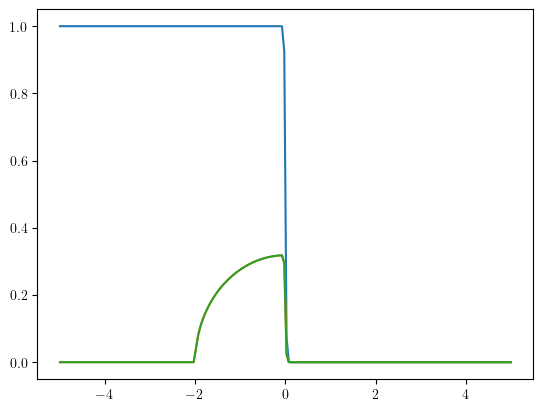

In [1897]:
#plt.plot(ws,y_square)
plt.plot(ws,fermi_dat)
plt.plot(ws,y_bethe_fermi)
plt.plot(ws,y_bethe)

(200,)

In [16]:
bethe_lattice_dos([1,2,3])

array([0.27566445, 0.        , 0.        ])